# Operational Definition of Arthouse Cinema
## From Analytics to Action - DTU Spring 2026

**Case company:** Publikum (formerly Will & Agency)  
**Dataset:** `03-data/films_enriched.csv` (50,000 films, IMDb + TMDb + MovieLens enrichment)  
**Purpose:** Define what counts as "arthouse" in this project, compare operational candidates, and provide a reusable flag for downstream analysis.

---

### How to read this notebook

This notebook treats "arthouse" as an analytical working definition, not a timeless film-theory category. The goal is practical: give our project one reproducible way to segment the 50k film dataset so later analyses can focus on the films most relevant to Publikum's arthouse/festival positioning question.


## Table of Contents

1. [Setup and Imports](#1-setup)
2. [Dataset Audit](#2-dataset-audit)
3. [Literature and Project Framing](#3-framing)
4. [Candidate Signals in the Data](#4-signals)
5. [Candidate Definitions](#5-definitions)
6. [Comparative Analysis](#6-comparison)
7. [Sanity Checks: Examples, False Positives, False Negatives](#7-sanity-checks)
8. [Recommendation and Reusable Function](#8-recommendation)
9. [Open Questions and Known Limitations](#9-limitations)


<a id="1-setup"></a>
## 1. Setup and Imports

We start by making the notebook robust to being run from either the repository root or the notebook folder. The `MPLCONFIGDIR` line avoids Matplotlib trying to write cache files outside the sandboxed project environment during execution.


In [1]:
# Standard libraries
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Make Matplotlib execution reliable in restricted environments.
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

# Find project root by walking upward until 03-data exists.
PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / '03-data').exists() and (candidate / 'src').exists():
        PROJECT_ROOT = candidate
        break
os.chdir(PROJECT_ROOT)

os.makedirs('reports/figures', exist_ok=True)

from src.visualize import set_style, save_figure
from src.arthouse import (
    ARTHOUSE_KEYWORDS,
    FESTIVAL_TERMS,
    MAINSTREAM_RISK_KEYWORDS,
    SPECIALTY_LABELS,
    arthouse_signals,
    contains_any_term,
    is_arthouse,
    score_arthouse,
)

set_style()
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 140)

print(f'Working directory: {Path.cwd()}')
print('Libraries and project helpers loaded successfully.')


Working directory: /Users/jep/Desktop/DTU/from-analytics-to-action
Libraries and project helpers loaded successfully.


In [2]:
# Explicit auditable term lists used by the notebook. The canonical implementation
# lives in src/arthouse.py; these local bindings make the choices visible here.
NOTEBOOK_SPECIALTY_LABELS = ('a24', 'ifc films', 'ifc productions', 'janus films', 'criterion collection', 'criterion', 'neon', 'mubi', 'strand releasing', 'kino lorber', 'oscilloscope', 'sony pictures classics', 'film movement', 'music box films', 'magnolia pictures', 'zeitgeist films', 'artificial eye', 'curzon', 'mk2', 'celluloid dreams', 'films boutique', 'the match factory', 'wild bunch', 'good machine', 'new yorker films', 'milestone films', 'bfi', 'british film institute', 'cinema guild', 'grasshopper film', 'factory 25', 'kimstim', 'utopia', 'metrograph', 'sideshow', 'picturehouse', 'roadside attractions', 'bleecker street', 'cohen media', 'arrow films', 'icarus films', 'dogwoof', 'modern films', 'trigon-film')
NOTEBOOK_FESTIVAL_TERMS = ('cannes', 'sundance', 'venice', 'berlinale', 'berlin international film festival', 'toronto international film festival', 'tiff', 'locarno', 'rotterdam', 'tribeca', 'telluride', 'san sebastian', 'london film festival', 'film festival', "palme d'or", 'palme d’or', 'golden bear', 'golden lion', 'jury prize', 'festival')
NOTEBOOK_ARTHOUSE_KEYWORDS = ('art film', 'art documentary', 'avant-garde', 'avant garde', 'experimental film', 'experimental cinema', 'slow cinema', 'minimalism', 'surrealism', 'existentialism', 'alienation', 'loneliness', 'identity', 'human rights', 'refugee', 'racism', 'holocaust', 'genocide', 'war crime', 'dictatorship', 'political repression', 'blasphemy', 'homosexuality', 'lgbt', 'lgbtq', 'addiction', 'suicide', 'social realism', 'coming of age', 'world war ii', 'communism', 'poverty', 'immigration')
NOTEBOOK_MAINSTREAM_RISK_KEYWORDS = ('superhero', 'marvel', 'dc comics', 'sequel', 'franchise', 'blockbuster', 'based on comic book', 'explosion', 'car chase', 'alien invasion', 'disaster movie', 'zombie', 'slasher', 'gore', 'torture porn', 'exploitation', 'b-movie', 'erotica')

assert NOTEBOOK_SPECIALTY_LABELS == SPECIALTY_LABELS
assert NOTEBOOK_FESTIVAL_TERMS == FESTIVAL_TERMS
assert NOTEBOOK_ARTHOUSE_KEYWORDS == ARTHOUSE_KEYWORDS
assert NOTEBOOK_MAINSTREAM_RISK_KEYWORDS == MAINSTREAM_RISK_KEYWORDS

print('Notebook term lists match src.arthouse constants.')


Notebook term lists match src.arthouse constants.


<a id="2-dataset-audit"></a>
## 2. Dataset Audit

Constraint check: before defining anything, verify the columns we actually have. The analysis below uses only columns present in `films_enriched.csv`.


In [3]:
DATA_PATH = Path('03-data/films_enriched.csv')
df = pd.read_csv(DATA_PATH)

required_columns = [
    'originalTitle', 'releaseYear', 'runtimeMinutes', 'imdbRating', 'numberOfVotes',
    'genres', 'keywords', 'production', 'budget', 'revenue', 'tmdb_popularity',
    'tmdb_vote_average', 'tmdb_vote_count', 'original_language', 'production_countries',
    'firstLanguage', 'mainCountry', 'directors', 'writers'
]
missing_columns = [col for col in required_columns if col not in df.columns]
assert not missing_columns, f'Missing required columns: {missing_columns}'

print(f'Dataset shape: {df.shape[0]:,} films x {df.shape[1]:,} columns')
print(f'Loaded from: {DATA_PATH}')

column_audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
})
display(column_audit.loc[required_columns])


Dataset shape: 50,000 films x 61 columns
Loaded from: 03-data/films_enriched.csv


,dtype,non_null,null_pct
originalTitle,object,50000,0.00
releaseYear,float64,45808,8.38
runtimeMinutes,float64,36448,27.10
imdbRating,float64,26352,47.30
numberOfVotes,float64,26352,47.30
genres,object,45440,9.12
keywords,object,26586,46.83
production,object,42863,14.27
budget,float64,27646,44.71
revenue,float64,27646,44.71


In [4]:
# Key distribution checks used by the definitions.
rated = df[df['imdbRating'].notna() & df['numberOfVotes'].notna()]
rated_keyworded = rated[rated['keywords'].notna()]

quantile_table = pd.DataFrame({
    'imdbRating': rated['imdbRating'].quantile([0.10, 0.25, 0.50, 0.75, 0.90]),
    'numberOfVotes': rated['numberOfVotes'].quantile([0.10, 0.25, 0.50, 0.75, 0.90]),
    'tmdb_popularity': df['tmdb_popularity'].dropna().quantile([0.10, 0.25, 0.50, 0.75, 0.90]),
}).round(2)

pdf_vote_q25 = rated_keyworded['numberOfVotes'].quantile(0.25)
pdf_baseline_count = int(((rated_keyworded['imdbRating'] >= 7.0) & (rated_keyworded['numberOfVotes'] <= pdf_vote_q25)).sum())

print(f'Rated films: {len(rated):,}')
print(f'Rated + keyworded films: {len(rated_keyworded):,}')
print(f'Bottom-quartile IMDb votes among rated + keyworded films: {pdf_vote_q25:.0f}')
print(f'PDF baseline reproduction, rating >= 7.0 and votes <= {pdf_vote_q25:.0f}: {pdf_baseline_count:,} films')
display(quantile_table)


Rated films: 26,352
Rated + keyworded films: 19,700
Bottom-quartile IMDb votes among rated + keyworded films: 33
PDF baseline reproduction, rating >= 7.0 and votes <= 33: 1,673 films


,imdbRating,numberOfVotes,tmdb_popularity
0.10,4.5,10.0,0.01
0.25,5.4,21.0,0.07
0.50,6.2,73.0,0.20
0.75,7.0,356.0,0.42
0.90,7.7,1824.7,0.73


<a id="3-framing"></a>
## 3. Literature and Project Framing

### Project provocation recap

The motivating PDF, `notebooks/arthouse/arthouse_provocation_final.pdf`, asks: **Which provocative themes are good provocation for arthouse cinema?** Its existing operational move was:

- **Niche reach:** bottom quartile of IMDb vote count among rated + keyworded films, which this notebook verifies as `<= 33` votes.
- **Quality threshold:** `imdbRating >= 7.0`.
- **Result:** 1,673 arthouse films in the rated + keyworded subset.

That framing is useful because it treats arthouse as a **high-rating / low-reach sweet spot**: critically recognized films that have not reached a mass IMDb audience.

### External framing used here

- David Bordwell's "art cinema" framing treats art cinema as a mode with conventions such as realism, authorial expressivity, ambiguity, and distance from classical cause-effect Hollywood narration. Source: [EBSCO abstract for Bordwell, *The Art Cinema as a Mode of Film Practice*](https://openurl.ebsco.com/contentitem/gcd%3A31286128?id=ebsco%3Agcd%3A31286128&sid=ebsco%3Aplink%3Acrawler).
- Film festivals are a distribution and evaluation circuit for new or outstanding films, connecting filmmakers, distributors, critics, and audiences. Source: [Britannica, film festival](https://www.britannica.com/art/film-festival).

### Candidate operational traditions

1. **Specialty distribution:** arthouse as films handled by specialty labels and arthouse distributors.
2. **Festival circuit:** arthouse as films with festival launch, awards, or festival-market evidence.
3. **Auteur/formal mode:** arthouse as director-driven, ambiguous, experimental, slow, or formally unusual work.
4. **Low-budget non-commercial cinema:** arthouse as lower-budget film outside blockbuster economics.
5. **Foreign-language / non-Hollywood cinema:** arthouse as non-English and non-US cinema reaching niche international audiences.

The dataset cannot observe form directly, so each tradition below is mapped to imperfect but auditable proxies.


<a id="4-signals"></a>
## 4. Candidate Signals Available in the Data

The enriched dataset gives us distribution labels, keyword tags, language/country metadata, budget and popularity proxies, and IMDb rating/reach. The table maps theory or industry concepts to available columns.


In [5]:
signal_map = pd.DataFrame([
    {
        'definition_family': 'Specialty distribution',
        'columns': 'production',
        'signal': 'Production/distribution string contains an explicit specialty label such as A24, IFC Films, Janus, Criterion, Neon, Mubi, Strand, Kino Lorber, Oscilloscope, Sony Pictures Classics, etc.',
        'caveat': 'The production field mixes producers, distributors, broadcasters, and release labels; boundary-safe string matching is used but this is still a proxy.'
    },
    {
        'definition_family': 'Festival circuit',
        'columns': 'keywords, production',
        'signal': 'Mentions of Cannes, Sundance, Venice, Berlinale, TIFF, Locarno, Rotterdam, Tribeca, Palme d\'Or, Golden Bear, Golden Lion, or generic festival terms.',
        'caveat': 'Festival absence does not mean no festival history; many festival premieres are not encoded.'
    },
    {
        'definition_family': 'Auteur / formal mode',
        'columns': 'keywords, directors, writers',
        'signal': 'Keywords such as art film, avant-garde, experimental film, slow cinema, surrealism, existentialism, social realism; director/writer overlap as a weak auteur proxy.',
        'caveat': 'Narrative ambiguity and style are not directly observable in the dataset.'
    },
    {
        'definition_family': 'Low-budget non-commercial',
        'columns': 'budget, tmdb_popularity, numberOfVotes',
        'signal': 'Positive budget up to 5 million USD, low TMDb popularity, or low IMDb votes.',
        'caveat': 'Budget has many zeros/missing values; zero is treated as unknown, not as a real zero budget.'
    },
    {
        'definition_family': 'Foreign-language / non-Hollywood',
        'columns': 'firstLanguage, original_language, mainCountry, production_countries',
        'signal': 'First/original language is not English and main country is not US.',
        'caveat': 'This over-includes ordinary domestic comedies, TV films, and local genre films; quality/reach gates are needed.'
    },
    {
        'definition_family': 'Niche prestige',
        'columns': 'imdbRating, numberOfVotes',
        'signal': 'High rating with low vote count, reproducing the provocation PDF logic.',
        'caveat': 'IMDb ratings are user-contributed and skew toward specific audience demographics.'
    },
])
display(signal_map)


,definition_family,columns,signal,caveat
0,Specialty distribution,production,"Production/distribution string contains an explicit specialty label such as A24, IFC Films, Janus, Criterion, Neon, Mubi, Strand, Kino L...","The production field mixes producers, distributors, broadcasters, and release labels; boundary-safe string matching is used but this is ..."
1,Festival circuit,"keywords, production","Mentions of Cannes, Sundance, Venice, Berlinale, TIFF, Locarno, Rotterdam, Tribeca, Palme d'Or, Golden Bear, Golden Lion, or generic fes...",Festival absence does not mean no festival history; many festival premieres are not encoded.
2,Auteur / formal mode,"keywords, directors, writers","Keywords such as art film, avant-garde, experimental film, slow cinema, surrealism, existentialism, social realism; director/writer over...",Narrative ambiguity and style are not directly observable in the dataset.
3,Low-budget non-commercial,"budget, tmdb_popularity, numberOfVotes","Positive budget up to 5 million USD, low TMDb popularity, or low IMDb votes.","Budget has many zeros/missing values; zero is treated as unknown, not as a real zero budget."
4,Foreign-language / non-Hollywood,"firstLanguage, original_language, mainCountry, production_countries",First/original language is not English and main country is not US.,"This over-includes ordinary domestic comedies, TV films, and local genre films; quality/reach gates are needed."
5,Niche prestige,"imdbRating, numberOfVotes","High rating with low vote count, reproducing the provocation PDF logic.",IMDb ratings are user-contributed and skew toward specific audience demographics.


In [6]:
print('Auditable specialty labels used in this notebook:')
display(pd.Series(NOTEBOOK_SPECIALTY_LABELS, name='specialty_label').to_frame())

print('Festival terms used in this notebook:')
display(pd.Series(NOTEBOOK_FESTIVAL_TERMS, name='festival_term').to_frame())

print('Arthouse / provocation keyword terms used in this notebook:')
display(pd.Series(NOTEBOOK_ARTHOUSE_KEYWORDS, name='arthouse_keyword').to_frame())

print('Mainstream-risk keywords subtracted in the composite score:')
display(pd.Series(NOTEBOOK_MAINSTREAM_RISK_KEYWORDS, name='mainstream_risk_keyword').to_frame())


Auditable specialty labels used in this notebook:


,specialty_label
0,a24
1,ifc films
2,ifc productions
3,janus films
4,criterion collection
5,criterion
6,neon
7,mubi
8,strand releasing
9,kino lorber


Festival terms used in this notebook:


,festival_term
0,cannes
1,sundance
2,venice
3,berlinale
4,berlin international film festival
5,toronto international film festival
6,tiff
7,locarno
8,rotterdam
9,tribeca


Arthouse / provocation keyword terms used in this notebook:


,arthouse_keyword
0,art film
1,art documentary
2,avant-garde
3,avant garde
4,experimental film
5,experimental cinema
6,slow cinema
7,minimalism
8,surrealism
9,existentialism


Mainstream-risk keywords subtracted in the composite score:


,mainstream_risk_keyword
0,superhero
1,marvel
2,dc comics
3,sequel
4,franchise
5,blockbuster
6,based on comic book
7,explosion
8,car chase
9,alien invasion


In [7]:
signals = arthouse_signals(df)
scores = score_arthouse(df)

signal_counts = pd.DataFrame({
    'films': signals.sum().astype(int),
    'share_pct': (signals.mean() * 100).round(2),
}).sort_values('films', ascending=False)

display(signal_counts)


,films,share_pct
non_english_non_us,38207,76.41
writer_director_overlap,28528,57.06
has_keywords,26586,53.17
niche_reach_broad,16367,32.73
low_tmdb_popularity,13754,27.51
niche_reach_pdf,9234,18.47
high_rating,7296,14.59
keyword_signal,3525,7.05
mainstream_risk,1999,4.00
specialty_label,1721,3.44


<a id="5-definitions"></a>
## 5. Candidate Definitions

We compare five candidate definitions. Each one is deliberately simple enough to audit.

- **PDF baseline:** exactly reproduces the provocation deck: `imdbRating >= 7.0`, `numberOfVotes <= 33`, and keywords present.
- **Strict canon:** specialty label plus festival signal. This is precise but small and can include popular canon titles.
- **Language/country-based:** non-English, non-US, high-rated, and niche-to-mid reach.
- **Keyword-based:** arthouse/provocation keyword, high-rated, and niche-to-mid reach.
- **Composite score:** weighted evidence score with a tunable threshold.

The final recommendation is an ensemble rather than a single pure theory because no single column captures arthouse cinema well.


In [8]:
evidence_signal = (
    signals['specialty_label']
    | signals['festival_signal']
    | signals['keyword_signal']
    | signals['low_budget']
)

candidate_masks = {
    'pdf_baseline': (
        df['keywords'].notna()
        & df['imdbRating'].ge(7.0)
        & df['numberOfVotes'].le(pdf_vote_q25)
    ),
    'strict_canon': signals['specialty_label'] & signals['festival_signal'],
    'language_country': (
        signals['non_english_non_us']
        & signals['high_rating']
        & signals['niche_reach_broad']
    ),
    'keyword_based': (
        signals['keyword_signal']
        & signals['high_rating']
        & signals['niche_reach_broad']
    ),
    'composite_score': (
        scores.ge(6)
        & signals['high_rating']
        & signals['niche_reach_broad']
        & evidence_signal
    ),
}

working_mask = is_arthouse(df)
candidate_masks['working_ensemble'] = working_mask

analysis_df = df.copy()
for name, mask in candidate_masks.items():
    analysis_df[name] = mask.fillna(False)
analysis_df['arthouse_score'] = scores
for col in signals.columns:
    analysis_df[col] = signals[col]

candidate_summary = []
for name, mask in candidate_masks.items():
    sub = analysis_df[mask]
    candidate_summary.append({
        'candidate': name,
        'films': int(mask.sum()),
        'share_of_dataset_pct': round(mask.mean() * 100, 2),
        'mean_imdb_rating': round(sub['imdbRating'].mean(), 2),
        'median_votes': round(sub['numberOfVotes'].median(), 0),
        'median_year': round(sub['releaseYear'].median(), 0),
        'specialty_label_pct': round(sub['specialty_label'].mean() * 100, 1),
        'festival_signal_pct': round(sub['festival_signal'].mean() * 100, 1),
        'keyword_signal_pct': round(sub['keyword_signal'].mean() * 100, 1),
        'non_english_non_us_pct': round(sub['non_english_non_us'].mean() * 100, 1),
    })

candidate_summary = pd.DataFrame(candidate_summary).set_index('candidate')
display(candidate_summary)


,films,share_of_dataset_pct,mean_imdb_rating,median_votes,median_year,specialty_label_pct,festival_signal_pct,keyword_signal_pct,non_english_non_us_pct
candidate,,,,,,,,,
pdf_baseline,1673,3.35,7.78,15.0,2012.0,0.3,1.1,8.5,66.1
strict_canon,173,0.35,6.91,8202.0,2013.0,100.0,100.0,58.4,61.8
language_country,2456,4.91,7.52,63.0,2010.0,3.9,1.5,9.8,100.0
keyword_based,329,0.66,7.44,138.0,2008.0,9.4,2.4,100.0,72.9
composite_score,404,0.81,7.42,139.0,2010.0,34.4,11.1,59.2,81.9
working_ensemble,1704,3.41,7.57,20.0,2011.0,18.0,13.1,26.2,88.7


In [9]:
# Candidate overlap matrix: row candidate as denominator.
candidate_names = list(candidate_masks.keys())
overlap = pd.DataFrame(index=candidate_names, columns=candidate_names, dtype=float)
for row_name in candidate_names:
    row_mask = candidate_masks[row_name]
    denom = row_mask.sum()
    for col_name in candidate_names:
        both = (row_mask & candidate_masks[col_name]).sum()
        overlap.loc[row_name, col_name] = both / denom * 100 if denom else np.nan

display(overlap.round(1))


,pdf_baseline,strict_canon,language_country,keyword_based,composite_score,working_ensemble
pdf_baseline,100.0,0.0,18.8,2.6,2.2,70.1
strict_canon,0.0,100.0,2.3,1.2,5.2,100.0
language_country,12.8,0.2,100.0,9.8,13.5,25.2
keyword_based,13.1,0.6,72.9,100.0,72.6,75.7
composite_score,9.2,2.2,81.9,59.2,100.0,100.0
working_ensemble,68.8,10.2,36.3,14.6,23.7,100.0


<a id="6-comparison"></a>
## 6. Comparative Analysis

The next figures compare subset size, year distribution, country distribution, and rating distribution. They use the same visual style as the existing project notebooks.


Saved reports/figures/arthouse_definition_candidate_sizes.png


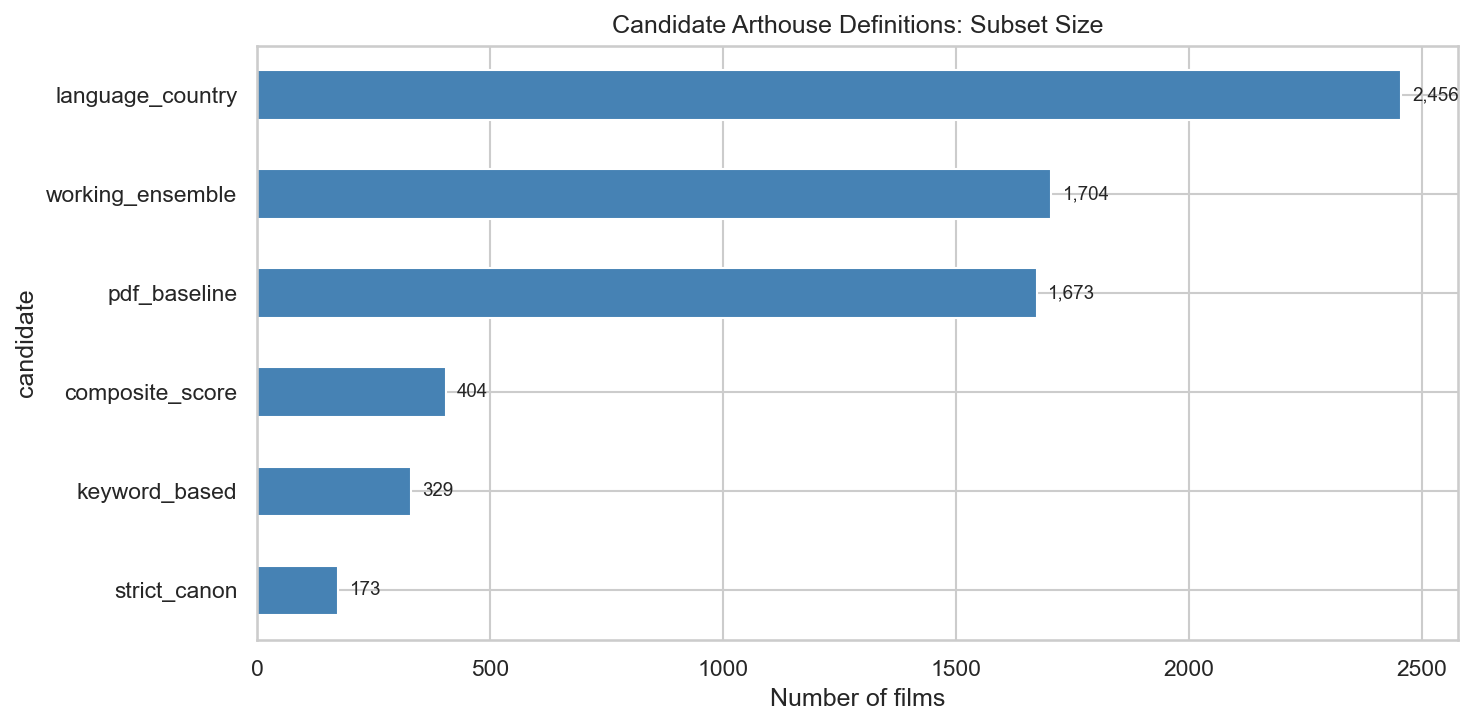

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_counts = candidate_summary['films'].sort_values()
plot_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of films')
ax.set_title('Candidate Arthouse Definitions: Subset Size')
for i, value in enumerate(plot_counts.values):
    ax.text(value + 25, i, f'{int(value):,}', va='center', fontsize=9)
plt.tight_layout()
save_figure(fig, 'arthouse_definition_candidate_sizes')
plt.show()


,pdf_baseline,strict_canon,language_country,keyword_based,composite_score,working_ensemble
1950,25,2,82,7,8,30
1960,26,5,126,20,21,45
1970,53,5,138,20,27,70
1980,54,2,141,18,23,62
1990,124,9,194,41,40,141
2000,275,28,367,57,66,269
2010,709,105,787,109,154,703
2020,255,15,458,36,48,234


Saved reports/figures/arthouse_definition_year_distribution.png


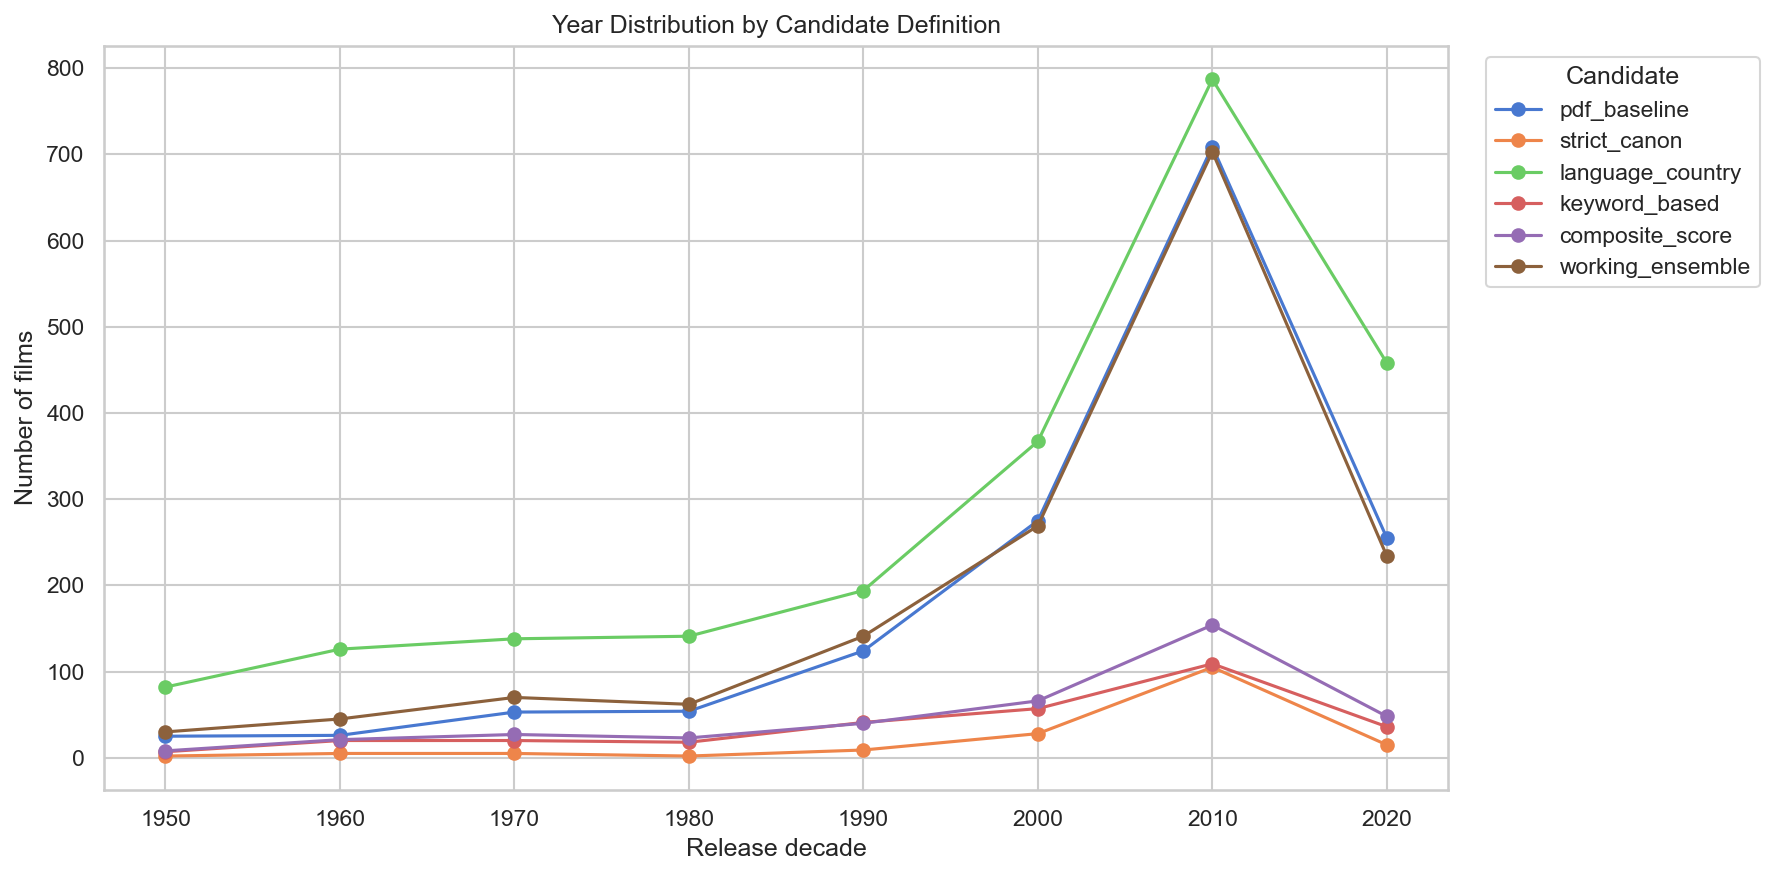

In [11]:
# Year distribution by decade.
year_df = analysis_df.dropna(subset=['releaseYear']).copy()
year_df['decade'] = (year_df['releaseYear'].astype(int) // 10) * 10
recent_year_df = year_df[year_df['decade'].between(1950, 2020)]

decade_counts = pd.DataFrame(index=sorted(recent_year_df['decade'].unique()))
for name, mask in candidate_masks.items():
    decade_counts[name] = recent_year_df.loc[mask.reindex(recent_year_df.index), 'decade'].value_counts().sort_index()
decade_counts = decade_counts.fillna(0).astype(int)

display(decade_counts.tail(10))

fig, ax = plt.subplots(figsize=(12, 6))
for name in candidate_names:
    ax.plot(decade_counts.index, decade_counts[name], marker='o', label=name)
ax.set_xlabel('Release decade')
ax.set_ylabel('Number of films')
ax.set_title('Year Distribution by Candidate Definition')
ax.legend(title='Candidate', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_figure(fig, 'arthouse_definition_year_distribution')
plt.show()


,pdf_baseline,strict_canon,language_country,keyword_based,composite_score,working_ensemble
FR,166,48,349,61,93,273
DE,256,9,309,34,46,267
GB,359,49,69,54,50,164
IT,127,9,241,26,25,147
ES,122,5,161,15,23,134
CH,56,2,75,8,17,64
AT,55,3,55,9,13,62
NL,67,3,95,13,16,59
GR,41,3,81,16,15,53
DK,34,13,56,5,5,47


Saved reports/figures/arthouse_definition_country_distribution.png


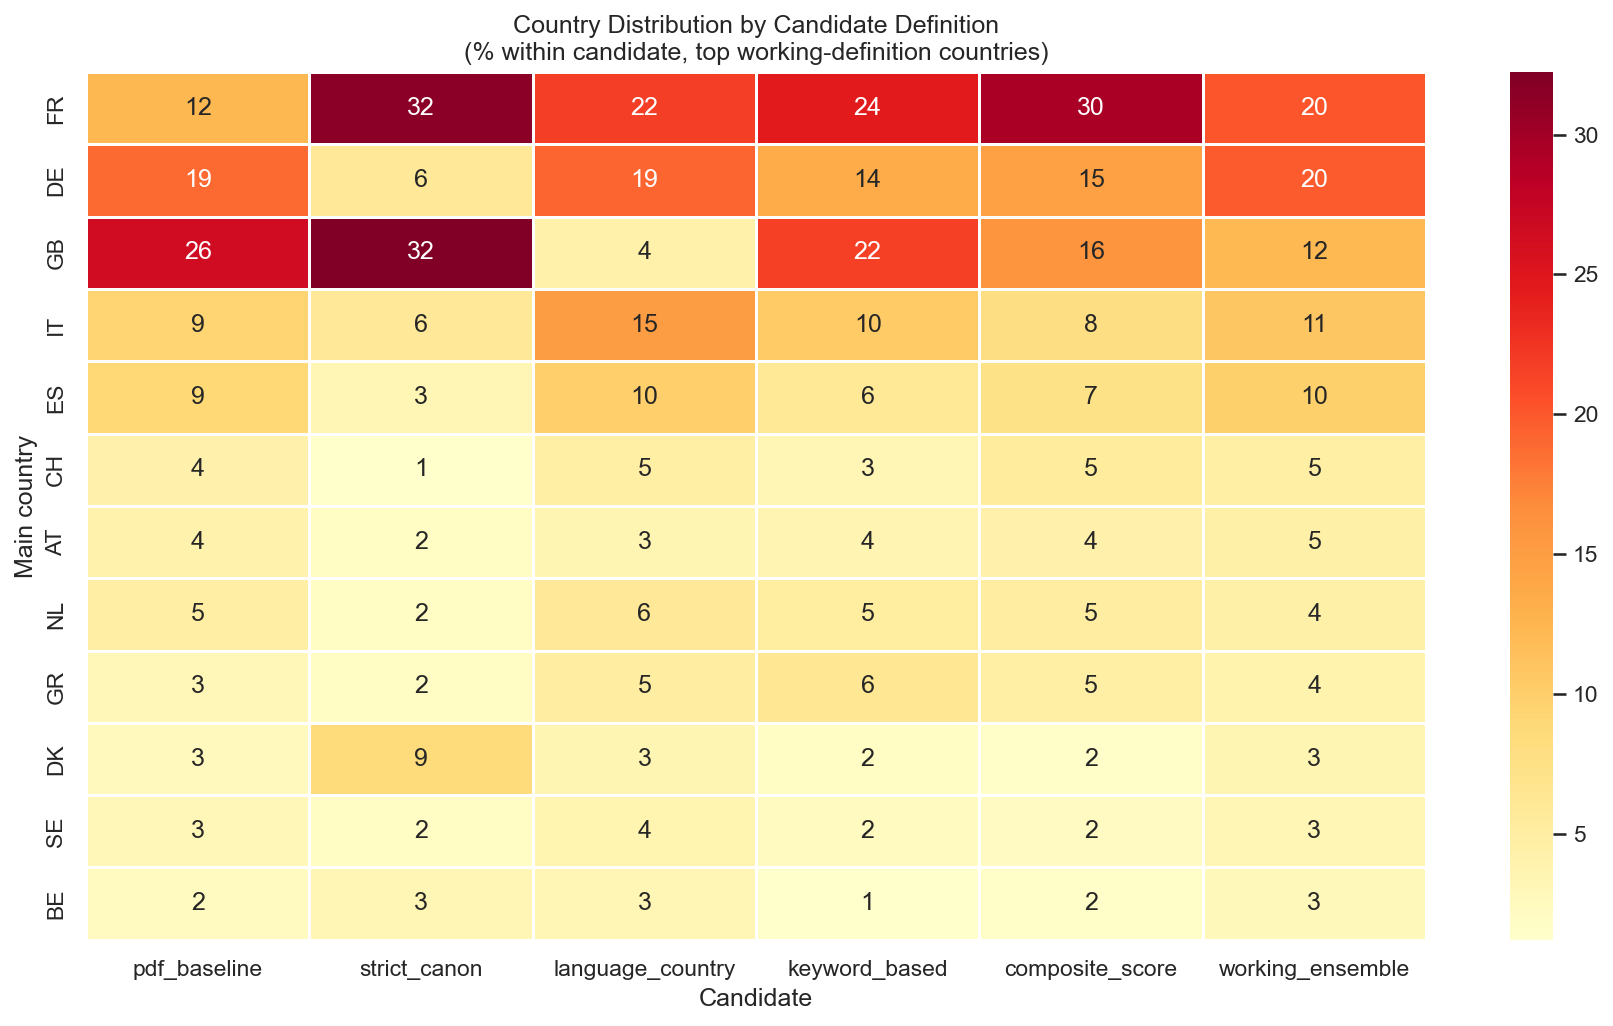

In [12]:
# Country distribution: top countries in the recommended working definition.
top_countries = analysis_df.loc[working_mask, 'mainCountry'].value_counts().head(12).index.tolist()
country_matrix = pd.DataFrame(index=top_countries)
for name, mask in candidate_masks.items():
    country_matrix[name] = analysis_df.loc[mask & analysis_df['mainCountry'].isin(top_countries), 'mainCountry'].value_counts()
country_matrix = country_matrix.fillna(0).astype(int)

country_pct = country_matrix.div(country_matrix.sum(axis=0), axis=1).fillna(0) * 100

display(country_matrix)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(country_pct, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Country Distribution by Candidate Definition\n(% within candidate, top working-definition countries)')
ax.set_xlabel('Candidate')
ax.set_ylabel('Main country')
plt.tight_layout()
save_figure(fig, 'arthouse_definition_country_distribution')
plt.show()


,count,mean,std,min,25%,50%,75%,max
candidate,,,,,,,,
composite_score,404.0,7.42,0.45,7.0,7.1,7.3,7.6,9.7
keyword_based,329.0,7.44,0.46,7.0,7.1,7.3,7.6,9.3
language_country,2456.0,7.52,0.52,7.0,7.1,7.4,7.8,9.9
pdf_baseline,1673.0,7.78,0.61,7.0,7.3,7.7,8.2,10.0
strict_canon,173.0,6.91,0.67,4.3,6.5,7.0,7.3,8.2
working_ensemble,1704.0,7.57,0.63,4.3,7.2,7.5,7.9,10.0


Saved reports/figures/arthouse_definition_rating_distribution.png


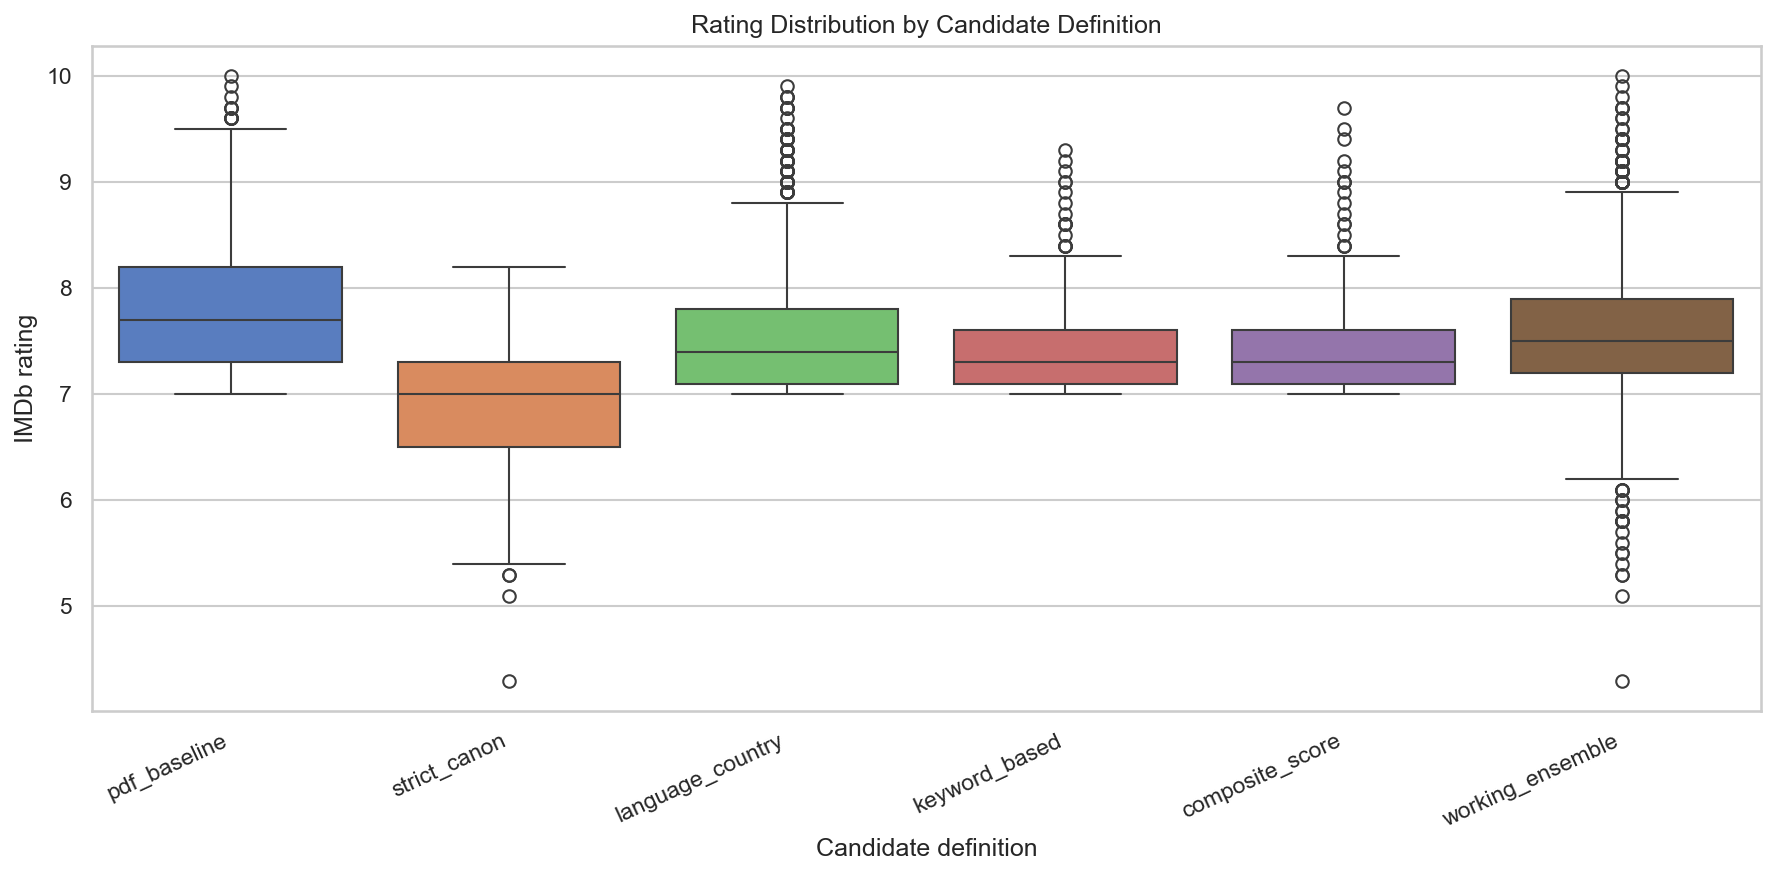

In [13]:
# Rating distribution. Use long form so each candidate can appear independently.
rating_rows = []
for name, mask in candidate_masks.items():
    for rating in analysis_df.loc[mask, 'imdbRating'].dropna():
        rating_rows.append({'candidate': name, 'imdbRating': rating})
rating_long = pd.DataFrame(rating_rows)

display(rating_long.groupby('candidate')['imdbRating'].describe().round(2))

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=rating_long, x='candidate', y='imdbRating', ax=ax, palette='muted')
ax.set_xlabel('Candidate definition')
ax.set_ylabel('IMDb rating')
ax.set_title('Rating Distribution by Candidate Definition')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
save_figure(fig, 'arthouse_definition_rating_distribution')
plt.show()


<a id="7-sanity-checks"></a>
## 7. Sanity Checks: Examples, False Positives, False Negatives

There is no hand-labeled arthouse ground truth in the dataset, so the false-positive and false-negative lists below are **heuristic boundary checks**:

- **Top examples** are high-scoring or high-rated titles included by a candidate.
- **Likely false positives** are included titles with warning signs such as high mass reach, mainstream-risk keywords, English/US context without other evidence, or weak evidence.
- **Likely false negatives** are titles excluded by a candidate but included by the recommended ensemble.

These tables are meant for human review, not as definitive labels.


In [14]:
example_cols = [
    'originalTitle', 'releaseYear', 'mainCountry', 'firstLanguage', 'genres',
    'imdbRating', 'numberOfVotes', 'arthouse_score', 'production', 'keywords'
]

candidate_order = ['pdf_baseline', 'strict_canon', 'language_country', 'keyword_based', 'composite_score']

def compact_examples(frame, n=10):
    cols = [col for col in example_cols if col in frame.columns]
    return frame[cols].head(n).reset_index(drop=True)


def warning_reason(row):
    reasons = []
    if row.get('mainstream_risk', False):
        reasons.append('mainstream-risk keyword')
    if pd.notna(row.get('numberOfVotes')) and row.get('numberOfVotes') > 10000:
        reasons.append('mass-reach votes')
    if not row.get('non_english_non_us', False):
        reasons.append('English/US or missing language-country niche')
    if pd.notna(row.get('imdbRating')) and row.get('imdbRating') < 7.0:
        reasons.append('rating below 7.0')
    if not (row.get('specialty_label', False) or row.get('festival_signal', False) or row.get('keyword_signal', False) or row.get('low_budget', False)):
        reasons.append('thin arthouse evidence')
    return '; '.join(reasons) if reasons else 'boundary case for human review'


def likely_false_positives(name, n=10):
    pool = analysis_df[candidate_masks[name]].copy()
    pool['warning_reason'] = pool.apply(warning_reason, axis=1)
    pool['warning_score'] = (
        pool['mainstream_risk'].astype(int) * 4
        + pool['numberOfVotes'].fillna(0).gt(10000).astype(int) * 3
        + (~pool['non_english_non_us']).astype(int)
        + (~(pool['specialty_label'] | pool['festival_signal'] | pool['keyword_signal'] | pool['low_budget'])).astype(int) * 2
        + pool['imdbRating'].fillna(0).lt(7.0).astype(int) * 3
    )
    pool = pool.sort_values(['warning_score', 'numberOfVotes', 'arthouse_score'], ascending=[False, False, True])
    cols = ['warning_reason'] + [col for col in example_cols if col in pool.columns]
    return pool[cols].head(n).reset_index(drop=True)


def likely_false_negatives(name, n=10):
    pool = analysis_df[(~candidate_masks[name]) & working_mask].copy()
    pool = pool.sort_values(['arthouse_score', 'imdbRating', 'numberOfVotes'], ascending=[False, False, False])
    cols = [col for col in example_cols if col in pool.columns]
    return pool[cols].head(n).reset_index(drop=True)

for name in candidate_order:
    display(Markdown(f'### {name}: top 10 included examples'))
    top = analysis_df[candidate_masks[name]].sort_values(
        ['arthouse_score', 'imdbRating', 'numberOfVotes'],
        ascending=[False, False, False]
    )
    display(compact_examples(top, 10))

    display(Markdown(f'### {name}: 10 likely false positives / boundary cases'))
    display(likely_false_positives(name, 10))

    display(Markdown(f'### {name}: 10 likely false negatives relative to the recommended ensemble'))
    display(likely_false_negatives(name, 10))


### pdf_baseline: top 10 included examples

,originalTitle,releaseYear,mainCountry,firstLanguage,genres,imdbRating,numberOfVotes,arthouse_score,production,keywords
0,Maisie,2021.0,GB,en,Documentary,8.0,29.0,9,"Bohemia Media, Proper Charlie Productions, BFI Doc Society Fund","lgbtq, drag queens, gay interest, old age, health issues"
1,La présence réelle,1984.0,FR,fr,NaN,7.5,26.0,9,"France 3, Institut National de l'Audiovisuel (INA)","experimental film, avant garde, essay, video disc, virtual, fictional documentary, gothic horror, written by director, thespian, acting,..."
2,Smaragda: I Got Thick Skin and I Can't Jump,2024.0,CY,el,Drama,8.7,23.0,8,"Bark Like a Cat Films, Fullmoon Productions, Master and Slave, Movies and Stories, White Balance Rentals","dating, feminism, coming of age, social media, ecological"
3,B comme Béjart,2002.0,CH,fr,Documentary,7.3,24.0,8,"Nikkatsu, CAB Productions, MK2 Diffusion, CAB Productions, Télévision Suisse-Romande (TSR), ARTE, Rhône-Alpes Cinéma, Radio Télévision B...","ballet, choreography, dance, dancing"
4,Blues,2012.0,DE,de,Drama,9.0,33.0,7,"Barbara Kowa Films, Vivàsvan","woman, breakup, suicide, forest, telephone, loneliness, despair, monologue, independent film, based on play"
5,The Kids Aren't Alright,2016.0,IE,en,Drama,8.8,22.0,7,Untold Stories Productions,"homosexuality, suicide, school, youth, teenager, ireland"
6,Kolysanka,1986.0,PL,pl,Drama,8.2,21.0,7,"FDF S.A., Zespol Filmowy ""Zodiak""",holocaust
7,80000 Thoughts,2014.0,DK,da,"Drama, Music",7.9,14.0,7,"One Love Factory House, One Love Factory House","dilemma, identity, death, sex, dance, exploration, spirituality, fantasies, transition from child to adult, love, existence"
8,Tríptico elemental de España,1996.0,ES,es,Documentary,7.8,28.0,7,"Museo Nacional Centro de Arte Reina Sofía, Cameo, Filmin","spanish, inventor, video art, art film, granada, alhambra spain, juan de juni, galicia, triptych, projections, compilation of short film..."
9,Lost and Spaced,2020.0,GB,en,Comedy,7.8,24.0,7,Indie Rights,"dark comedy, guitar, mafia, surrealism, family relationships, young, church, stoner, drug use"


### pdf_baseline: 10 likely false positives / boundary cases

,warning_reason,originalTitle,releaseYear,mainCountry,firstLanguage,genres,imdbRating,numberOfVotes,arthouse_score,production,keywords
0,mainstream-risk keyword; English/US or missing language-country niche; thin arthouse evidence,Pure Bloodlines: Blood's Thicker Than Water,2014.0,GB,en,"Action, Adventure, Comedy, Drama, Fantasy, Horror, Romance",7.4,19.0,0,"Horler Knights Productions, Horler Knights Productions","martial arts action, reference to marvel comics, supernatural power, twin, psychotronic film, dc comics, vampire, good versus evil, mart..."
1,mainstream-risk keyword; English/US or missing language-country niche; thin arthouse evidence,The Three Dumas,2007.0,GB,en,Documentary,8.8,10.0,0,"Trenhorne Films, Trenhorne Films, Trenhorne Films, Stanley Productions","superhero, reenactment"
2,mainstream-risk keyword; English/US or missing language-country niche; thin arthouse evidence,"Black Wind, White Land: Living with Chernobyl",1993.0,IE,en,Documentary,8.4,9.0,0,Dreamchaser Productions,explosion
3,mainstream-risk keyword; thin arthouse evidence,Smanderoon: With a Vengeance,2013.0,FI,sv,"Action, Comedy, Thriller",7.3,27.0,3,"West Bay Entertainment, Öppet Bolag","police, explosion, death, hero, cell phone, arrest, police officer, police station, bomb, internet, cell phone tower, tv repairman, twin..."
4,mainstream-risk keyword; thin arthouse evidence,Capo di Famiglia III,2022.0,NL,nl,Drama,9.4,22.0,2,"CVR Productions, Mohr Productions","third part, sequel, numbered sequel, roman numeral in title"
5,mainstream-risk keyword; thin arthouse evidence,Juego de niños,1999.0,ES,es,"Animation, Action, Sci-Fi",8.7,18.0,2,"Canal+ España, Canal 9 Televisió Valenciana, Canal+ España","alien invasion, alien invasion sci fi, alien"
6,mainstream-risk keyword; thin arthouse evidence,The Harvest,2017.0,IT,it,"Documentary, Drama, Musical",7.4,17.0,2,"OpenDDB, SMK Factory","worker, exploitation, bhangra"
7,mainstream-risk keyword; thin arthouse evidence,Schlaflose Nächte,1988.0,CH,gsw,Drama,7.7,15.0,2,"Cactus Film, Mega Film Verleih, DRS, Kyros-Film, Schweizer Fernsehen (SF), Vulcano M Film und Fernsehproduktion, Westdeutscher Rundfunk ...",sequel
8,mainstream-risk keyword; thin arthouse evidence,Taurins Senior,2023.0,AT,lv,"Comedy, Drama",7.2,13.0,1,"Mojo Raiser Production, ArtEvi films, Marleen Paeschke Filmproduktion, tremendous4 Films","son, old man, death, mother, home, return, latvia, riga, sequel, father, family relationships, homecare, sickness, love, fake documentar..."
9,mainstream-risk keyword; thin arthouse evidence,Bob a Bobek ve filmu: Na stope Mrkvojeda,2024.0,CZ,cs,"Animation, Comedy, Family, Fantasy",9.2,10.0,1,"Forum Film, BoBa FILM","garden, based on tv series, male name in title, anthropomorphic rabbit, top hat, czech psychotronic film, gardener, talking rabbit, czec..."


### pdf_baseline: 10 likely false negatives relative to the recommended ensemble

...

,originalTitle,releaseYear,mainCountry,firstLanguage,genres,imdbRating,numberOfVotes,arthouse_score,production,keywords
0,Mijn Rembrandt,2019.0,NL,en,Documentary,7.0,452.0,11,"Strand Releasing, Cineart, Cinephil, Cinema Mondo, Dogwoof, Unplugged, Yleisradio (YLE), Discours Film, CPH: DOX, FeverFilm, Montclair F...","art documentary, rembrandt, hoogendijk, family relationships, inheritance, art auction, painting, art collector, netherlands, rembrandt ..."
1,Film: The Living Record of Our Memory,2021.0,ES,en,Documentary,7.9,278.0,10,"Kino Lorber, Lost & Found, Filmoption International, El Grifilm, Filmoption International","cinephilia, film preservation, film archive, video library, film history, reference to rko radio pictures, reference to henri langlois, ..."
2,El telón de azúcar,2005.0,FR,es,"Documentary, History",7.5,94.0,10,"First Run/Icarus Films, Arte Cinema, Epicentre Films, Four Films, Paraïso Productions","dream, cuba, f rated, student, cuban history, school, havana cuba, emigration, education, communism, cold war, autobiographical"
3,"Sobibór, 14 octobre 1943, 16 heures",2001.0,FR,he,"Documentary, History, War",7.4,620.0,10,"New Yorker Films, Copiapoa Film, Mermaid Film, Paradiso Entertainment, Mars Distribution, absolut MEDIEN, Why Not Productions, Les Films...","holocaust survivor, holocaust, date in title, year in title, 20th century, 1940s, year 1943, genocide, shoah, jewish resistance, nazi ge..."
4,Numéro zéro,1971.0,FR,fr,Documentary,7.1,122.0,10,"The Criterion Channel, Capricci Films","director, independent filmmaker, independent cinema, speaking french, grandmother, son, father, family relationships, existential poetry..."
5,Si linghun,2018.0,CH,cmn,"Documentary, History",8.0,402.0,9,"Icarus Films, Adok Films, Les Acacias, Moviola, Grasshopper Film, Leopardo Filmes, Les Films d'Ici, Arte France Cinéma, Adok Films, Cann...","1960s, china, communist china, rural china, gansu china, chinese history, people's republic of china, gobi desert, 1950s, reference to m..."
6,Maisie,2021.0,GB,en,Documentary,8.0,29.0,9,"Bohemia Media, Proper Charlie Productions, BFI Doc Society Fund","lgbtq, drag queens, gay interest, old age, health issues"
7,Enemies of the People,2009.0,GB,en,"Documentary, Crime, History",7.7,566.0,9,"International Film Circuit, Dogwoof, NHK BS1, Old Street Films, OutPost Facilities","khmer rouge, crime against humanity, genocide, communist utopia, mass murder, torture, forced labor, communism, ideology, cambodia, inve..."
8,Exit,2005.0,CH,fr,Documentary,7.6,47.0,9,First Run/Icarus Films,suicide
9,La présence réelle,1984.0,FR,fr,NaN,7.5,26.0,9,"France 3, Institut National de l'Audiovisuel (INA)","experimental film, avant garde, essay, video disc, virtual, fictional documentary, gothic horror, written by director, thespian, acting,..."


### composite_score: 10 likely false positives / boundary cases

,warning_reason,originalTitle,releaseYear,mainCountry,firstLanguage,genres,imdbRating,numberOfVotes,arthouse_score,production,keywords
0,mainstream-risk keyword; English/US or missing language-country niche,Fairytale of Kathmandu,2007.0,IE,en,Documentary,7.3,75.0,6,"The Cinema Guild, Journeyman Pictures, Journeyman Pictures, Journeyman Pictures, Media, Vinegar Hill Productions NI","child abuse, teenage boy, poet, irish, innocence, writer, tourist, kathmandu nepal, exploitation"
1,English/US or missing language-country niche,Kingdom of Us,2017.0,GB,en,"Documentary, Drama",7.0,982.0,8,"Netflix, Netflix, BFI Film Fund, Pulse Films, Raw Cut Television, Freeway CAM B.V.",suicide
2,English/US or missing language-country niche,Sonita,2015.0,DE,en,"Documentary, Biography, Music",7.6,895.0,7,"Women Make Movies, Real Fiction, Septième Factory, United People, NHK BS1, Yleisradio (YLE), good movies!, TAG/TRAUM Filmproduktion, Int...","character name as title, tradition, iran, refugee, title directed by female, triple f rated, daydreaming, reference to youtube, piano, s..."
3,English/US or missing language-country niche,Evelyn,2018.0,GB,en,Documentary,7.2,886.0,8,"Netflix, Netflix, BBC Film, British Film Institute (BFI), Grain Media, Violet Films, Air-Edel Associates, Air-Edel Recording Studios, Fi...","mental health, coping with grief, family bonding, suicide"
4,English/US or missing language-country niche,Om våld,2014.0,SE,en,"Documentary, Drama, History, War",7.5,813.0,8,"Kino Lorber, Happiness Distribution, Against Gravity, Alambique Filmes, Films Boutique, Yleisradio (YLE), Final Cut for Real, Helsinki-f...","struggle, 1970s, 1960s, revolution, violence, colony, structural racism, independence, archive footage, imperialism, capitalism, depriva..."
5,English/US or missing language-country niche,London,1994.0,GB,en,Documentary,7.3,783.0,9,"Zeitgeist Films, BFI Video, E.D. Distribution, BFI Production, Koninck Studios","london england, travelogue, english culture, flaneur, essay film, cruise ship, reference to horace walpole, reference to joshua reynolds..."
6,English/US or missing language-country niche,Max Richter's Sleep,2019.0,GB,NaN,"Documentary, Music",7.2,657.0,7,"Dogwoof, At Entertainment, Globe Productions, JA Films, Sundance Film Festival",chaos
7,English/US or missing language-country niche,Les années lumière,1981.0,CH,en,Drama,7.3,581.0,6,"New Yorker Films, Citel Films, Gaumont, Newhart Diffusion, Película, Artificial Eye, filmo - Verein CH.Film, Gaumont, Les Productions Au...","artistic creation, young, man, drifter, flying machine, junkyard, based on novel"
8,English/US or missing language-country niche,My Love Affair with Marriage,2022.0,LU,en,"Animation, Comedy, Drama, Musical",7.1,571.0,7,"8 Above, Filmin, Tamasa Distribution, Tamasa Distribution, Filmin, Filmin, HBO Central Europe, The Marriage Project, Studio Locomotive, ...","sakhalin, boy wears a dress, latvia, soviet union, virginity, girl, mother, menarche, menstruation, biology, neuron, neurotransmitter, b..."
9,English/US or missing language-country niche,Anton Corbijn Inside Out,2012.0,NL,en,"Documentary, Biography",7.0,566.0,6,"Music Box Films, A-Film Distribution, Synca Creations, Capelight Pictures, Bord Scannán na hÉireann / The Irish Film Board, CTM Films, F...","photographer, reference to nirvana, reference to herbert groenemeyer, reference to joy division, dropout, reference to the beatles, refe..."


### composite_score: 10 likely false negatives relative to the recommended ensemble

,originalTitle,releaseYear,mainCountry,firstLanguage,genres,imdbRating,numberOfVotes,arthouse_score,production,keywords
0,Zimna wojna,2018.0,PL,pl,"Drama, Music, Romance",7.5,63093.0,11,"Amazon Studios, Kino Swiat, Curzon Film Distributors, Diaphana Distribution, Curzon Film Distributors, Cinéart, Cinéart, Arthouse Traffi...","cold war, audition, musician, border crossing, choir, marriage, concert, poet, communist poland, 1950s, suicide, suicide pact, sex scene..."
1,Ben X,2007.0,BE,qbn,"Drama, Thriller",7.3,19490.0,11,"Film Movement, Bridge Entertainment Group, Distribution Company, Filmtrade, Future Film, Kinepolis Film Distribution (KFD), Kinowelt Fil...","faked death, imaginary friend, faked suicide, asperger's syndrome, bullying, male rear nudity, assisted suicide, high school, internet, ..."
2,Holy Motors,2012.0,FR,fr,"Drama, Fantasy",7.0,49744.0,11,"Indomina Group, Wild Bunch, Les Films du Losange, Must Käsi, TriArt Film, Noble Entertainment, Aerofilms, Arsenal Filmverleih, CGV Mars ...","experimental film, graveyard, fake beard and mustache, movie theater, school party, erotic dance, fashion, appointment, stabbing, knife,..."
3,Italiensk for begyndere,2000.0,DK,da,"Comedy, Drama, Romance",7.0,14070.0,11,"Buena Vista Home Entertainment, Alfa Films, Kamras Film Group, Kinowelt Filmverleih, Upstream Pictures, Zazie Films, Bir Film, CinemArt,...","church, hotel, restaurant, italian class, bakery, hairdresser, bechdel test passed, title directed by female, language class, language l..."
4,The Act of Killing,2012.0,GB,id,"Documentary, Biography, Crime, History, War",8.2,41722.0,10,"Drafthouse Films, Final Cut for Real, Cinema Delicatessen, Det Danske Filminstitut, Edko Films, Filmcenter Trianon, Maison Motion, Neue ...","executioner, biographical documentary, death squad, mass killing, surrealism, retching, self justification, political rally, gangster, t..."
5,Colectiv,2019.0,RO,ro,"Documentary, Crime",8.1,13725.0,10,"Participant, Bad Unicorn, Cinema Delicatessen, Cinobo, Dogwoof, Sophie Dulac Distribution, Transformer, Films4You, HBO España, Madman En...","corruption, investigative journalism, journalism, night club fire, politics, pharmaceutical company, health minister, media manipulation..."
6,Visages villages,2017.0,FR,fr,"Documentary, Adventure",7.8,13800.0,10,"Cohen Media Group, Anticipate Pictures, Cinemanse, Cinéart, Curzon Film Distributors, Curzon Film Distributors, IFA, Interior13 Cine, On...","france, rural setting, countryside, on the road, cistern, pantheon, watching a video, friend, friendship, older woman younger man relati..."
7,Le corbeau,1943.0,FR,fr,"Crime, Drama, Horror, Mystery, Thriller",7.8,11295.0,10,"Westport International, Films Sonores Tobis, Terrafilm, Yleisradio (YLE), Film Office, Optimum Releasing, StudioCanal, The Criterion Col...","secret, doctor, slander, writer, revenge, pregnancy, suicide, church, deception, cheating wife, reference to pierre corneille, letter, v..."
8,Trilogia: To livadi pou dakryzei,2004.0,GR,el,"Drama, History, Romance",7.8,5442.0,10,"New Yorker Films, Celluloid Dreams, Bac Films, Istituto Luce, Artificial Eye, Bright Angel Distribution, Filmcoopi, France Eigasha, New ...","ottoman empire, world war 1, adoptive brother adopted sister love, world war two, 1940s, adolescent boy, adoptive brother adopted sister..."
9,Boze Cialo,2019.0,PL,pl,Drama,7.7,22620.0,10,"Film Movement, Kino Swiat, Bodega Films, New Europe Film Sales, Alameda Films, Arsenal Filmverleih, Asociace Ceských Filmových Klubu (AC...","priest, sex scene, grief, funeral, mayor, assumed identity, fake identity, juvenile detention center, male rear nudity, catholic church,..."


<a id="8-recommendation"></a>
## 8. Recommendation and Reusable Function

### Recommended project definition

Use the `working_ensemble` implemented in `src/arthouse.py` as the project's default arthouse flag.

Why this ensemble fits the provocation framing:

1. It preserves the deck's core insight: arthouse is a high-rating / low-reach zone, not simply foreign film or independent film.
2. It narrows the old baseline by requiring either arthouse evidence or non-English/non-US context, reducing pure "tiny-vote high-rating" noise.
3. It adds a strict specialty/festival path for films that are clearly arthouse by industry circulation, even if they are too visible to satisfy the low-vote proxy.
4. It adds a composite path for films with multiple weaker signals: festival/specialty/keyword/budget plus quality and niche-to-mid reach.

The function to reuse elsewhere is:

```python
from src.arthouse import is_arthouse

arthouse_mask = is_arthouse(df)
arthouse_df = df[arthouse_mask]
```


In [15]:
# Smoke test the reusable function and show the final working subset.
arthouse_mask = is_arthouse(df)
arthouse_df = df[arthouse_mask].copy()

print(f'Working definition selects {arthouse_mask.sum():,} films ({arthouse_mask.mean() * 100:.2f}% of dataset).')
print(f'Mean IMDb rating: {arthouse_df["imdbRating"].mean():.2f}')
print(f'Median IMDb votes: {arthouse_df["numberOfVotes"].median():,.0f}')
print(f'Median release year: {arthouse_df["releaseYear"].median():.0f}')

working_signal_profile = pd.DataFrame({
    'working_ensemble_count': signals[arthouse_mask].sum().astype(int),
    'working_ensemble_pct': (signals[arthouse_mask].mean() * 100).round(1),
    'full_dataset_pct': (signals.mean() * 100).round(1),
})
display(working_signal_profile)

display(
    arthouse_df.assign(arthouse_score=scores[arthouse_mask])
    .sort_values(['arthouse_score', 'imdbRating', 'numberOfVotes'], ascending=[False, False, False])
    [example_cols]
    .head(20)
    .reset_index(drop=True)
)


Working definition selects 1,704 films (3.41% of dataset).
Mean IMDb rating: 7.57
Median IMDb votes: 20
Median release year: 2011


,working_ensemble_count,working_ensemble_pct,full_dataset_pct
specialty_label,306,18.0,3.4
festival_signal,224,13.1,1.3
keyword_signal,447,26.2,7.0
mainstream_risk,58,3.4,4.0
non_english_non_us,1512,88.7,76.4
high_rating,1623,95.2,14.6
niche_reach_pdf,1179,69.2,18.5
niche_reach_broad,724,42.5,32.7
low_budget,111,6.5,2.4
low_tmdb_popularity,872,51.2,27.5


,originalTitle,releaseYear,mainCountry,firstLanguage,genres,imdbRating,numberOfVotes,arthouse_score,production,keywords
0,Zimna wojna,2018.0,PL,pl,"Drama, Music, Romance",7.5,63093.0,11,"Amazon Studios, Kino Swiat, Curzon Film Distributors, Diaphana Distribution, Curzon Film Distributors, Cinéart, Cinéart, Arthouse Traffi...","cold war, audition, musician, border crossing, choir, marriage, concert, poet, communist poland, 1950s, suicide, suicide pact, sex scene..."
1,Ben X,2007.0,BE,qbn,"Drama, Thriller",7.3,19490.0,11,"Film Movement, Bridge Entertainment Group, Distribution Company, Filmtrade, Future Film, Kinepolis Film Distribution (KFD), Kinowelt Fil...","faked death, imaginary friend, faked suicide, asperger's syndrome, bullying, male rear nudity, assisted suicide, high school, internet, ..."
2,Holy Motors,2012.0,FR,fr,"Drama, Fantasy",7.0,49744.0,11,"Indomina Group, Wild Bunch, Les Films du Losange, Must Käsi, TriArt Film, Noble Entertainment, Aerofilms, Arsenal Filmverleih, CGV Mars ...","experimental film, graveyard, fake beard and mustache, movie theater, school party, erotic dance, fashion, appointment, stabbing, knife,..."
3,Italiensk for begyndere,2000.0,DK,da,"Comedy, Drama, Romance",7.0,14070.0,11,"Buena Vista Home Entertainment, Alfa Films, Kamras Film Group, Kinowelt Filmverleih, Upstream Pictures, Zazie Films, Bir Film, CinemArt,...","church, hotel, restaurant, italian class, bakery, hairdresser, bechdel test passed, title directed by female, language class, language l..."
4,Mijn Rembrandt,2019.0,NL,en,Documentary,7.0,452.0,11,"Strand Releasing, Cineart, Cinephil, Cinema Mondo, Dogwoof, Unplugged, Yleisradio (YLE), Discours Film, CPH: DOX, FeverFilm, Montclair F...","art documentary, rembrandt, hoogendijk, family relationships, inheritance, art auction, painting, art collector, netherlands, rembrandt ..."
5,The Act of Killing,2012.0,GB,id,"Documentary, Biography, Crime, History, War",8.2,41722.0,10,"Drafthouse Films, Final Cut for Real, Cinema Delicatessen, Det Danske Filminstitut, Edko Films, Filmcenter Trianon, Maison Motion, Neue ...","executioner, biographical documentary, death squad, mass killing, surrealism, retching, self justification, political rally, gangster, t..."
6,Colectiv,2019.0,RO,ro,"Documentary, Crime",8.1,13725.0,10,"Participant, Bad Unicorn, Cinema Delicatessen, Cinobo, Dogwoof, Sophie Dulac Distribution, Transformer, Films4You, HBO España, Madman En...","corruption, investigative journalism, journalism, night club fire, politics, pharmaceutical company, health minister, media manipulation..."
7,Film: The Living Record of Our Memory,2021.0,ES,en,Documentary,7.9,278.0,10,"Kino Lorber, Lost & Found, Filmoption International, El Grifilm, Filmoption International","cinephilia, film preservation, film archive, video library, film history, reference to rko radio pictures, reference to henri langlois, ..."
8,Visages villages,2017.0,FR,fr,"Documentary, Adventure",7.8,13800.0,10,"Cohen Media Group, Anticipate Pictures, Cinemanse, Cinéart, Curzon Film Distributors, Curzon Film Distributors, IFA, Interior13 Cine, On...","france, rural setting, countryside, on the road, cistern, pantheon, watching a video, friend, friendship, older woman younger man relati..."
9,Le corbeau,1943.0,FR,fr,"Crime, Drama, Horror, Mystery, Thriller",7.8,11295.0,10,"Westport International, Films Sonores Tobis, Terrafilm, Yleisradio (YLE), Film Office, Optimum Releasing, StudioCanal, The Criterion Col...","secret, doctor, slander, writer, revenge, pregnancy, suicide, church, deception, cheating wife, reference to pierre corneille, letter, v..."


In [16]:
# Save a compact CSV of the recommended titles for easy downstream inspection.
# This is an analysis artifact, not the canonical definition; src/arthouse.py is canonical.
out_cols = [
    'titleId', 'originalTitle', 'releaseYear', 'mainCountry', 'firstLanguage',
    'genres', 'imdbRating', 'numberOfVotes', 'arthouse_score'
]
export_df = arthouse_df.assign(arthouse_score=scores[arthouse_mask])
export_path = Path('reports/arthouse_working_definition_titles.csv')
export_df[[col for col in out_cols if col in export_df.columns]].to_csv(export_path, index=False)
print(f'Saved {export_path} with {len(export_df):,} rows for inspection.')


Saved reports/arthouse_working_definition_titles.csv with 1,704 rows for inspection.


<a id="9-limitations"></a>
## 9. Open Questions and Known Limitations

- **No ground truth labels:** The false-positive and false-negative lists are sanity checks, not validation against human-coded arthouse labels.
- **Production field ambiguity:** `production` mixes production companies, distributors, broadcasters, and release labels. Specialty-label hits are useful but not pure distribution evidence.
- **Festival evidence is sparse:** Festival history is rarely encoded systematically, so the strict canon definition is precise but under-inclusive.
- **IMDb vote count is a proxy:** Low votes can mean niche prestige, but it can also mean poor data coverage, very recent release, or local-only visibility.
- **IMDb ratings are biased:** Ratings reflect IMDb users, not festival juries, critics, Publikum's audience panels, or Danish arthouse cinemagoers.
- **Budget data is incomplete:** TMDb budget zeros are treated as unknown, so low-budget evidence only applies when a positive budget exists.
- **Language/country over-includes:** Non-English/non-US cinema contains mainstream local entertainment as well as arthouse. The recommended definition therefore combines language/country with rating, reach, and evidence signals.
- **Formal style is mostly invisible:** Key film-studies ideas such as ambiguity, realism, slow pacing, and authorial expressivity are only approximated through keywords and writer/director overlap.

### Practical next steps

Use `is_arthouse(df)` as the default segmentation in downstream notebooks. If a later qualitative review produces hand-labeled examples, recalibrate the score threshold and the keyword/specialty lists against that review.
